# DCN NEURON / BrainCell comparison


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import brainunit as u
import brainstate
from braincell import mech
from braincell.filter import at
from neuron import h

from validation.neuron.cell.dcn_su2015.parameters import DEFAULT_NRNMECH_PATH, SOURCE_MORPH_PATH, load_dcn15_params
from validation.neuron.cell.dcn_su2015.dcn_neuron import DCN as NeuronDCN
from validation.neuron.cell.dcn_su2015.dcn_braincell import DCN as BrainCellDCN

brainstate.environ.set(precision=64)


--No graphics will be displayed.


In [2]:
dt_ms = 0.1
duration_ms = 50.0
delay_ms = 10.0
stim_dur_ms = 30.0
amp_nA = 0.1
temperature_celsius = 32.0
v_init_mV = -65.0
params = load_dcn15_params(temperature_celsius=temperature_celsius)


In [3]:
neuron_dcn = NeuronDCN(
    SOURCE_MORPH_PATH,
    params=params,
    nrnmech_path=DEFAULT_NRNMECH_PATH,
    temperature_celsius=temperature_celsius,
    v_init_mV=v_init_mV,
).build()
stim = h.IClamp(neuron_dcn.root_soma(0.5))
stim.delay = delay_ms
stim.dur = stim_dur_ms
stim.amp = amp_nA
t_neuron = h.Vector().record(h._ref_t)
v_soma_neuron = h.Vector().record(neuron_dcn.root_soma(0.5)._ref_v)
h.cvode_active(0)
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.celsius = temperature_celsius
h.tstop = duration_ms
h.v_init = v_init_mV
h.finitialize(h.v_init)
h.run()

braincell_dcn = BrainCellDCN(params=params, temperature_celsius=temperature_celsius, v_init_mV=v_init_mV).build()
braincell_dcn.cell.place(at("soma", 0.5), mech.StateProbe(name="v_soma"))
braincell_dcn.cell.place(at("soma", 0.5), mech.CurrentClamp(delay=delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=amp_nA * u.nA))
braincell_dcn.cell.init_state()
braincell_dcn.cell.reset_state()
braincell_run = braincell_dcn.cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)


Text(0.5, 1.0, 'DCN soma voltage')

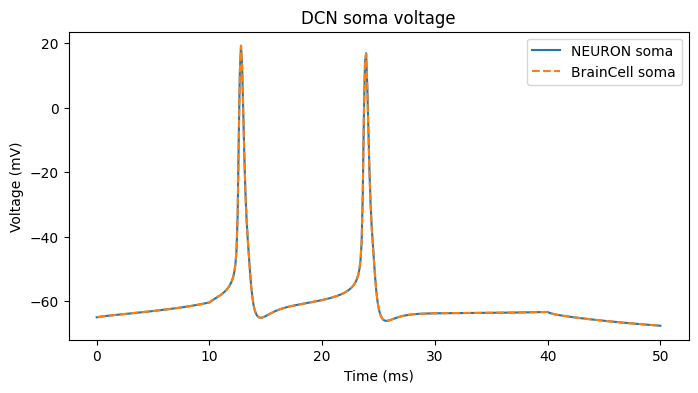

In [4]:
neuron_t = np.asarray(t_neuron, dtype=float).reshape(-1)
neuron_v = np.asarray(v_soma_neuron, dtype=float).reshape(-1)
braincell_v = np.asarray(braincell_run.traces["v_soma"].to_decimal(u.mV), dtype=float).reshape(-1)
braincell_t = (np.arange(braincell_v.shape[0], dtype=float) + 1.0) * dt_ms

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(neuron_t, neuron_v, label="NEURON soma")
ax.plot(braincell_t[: braincell_v.shape[0]], braincell_v, label="BrainCell soma", linestyle="--")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.legend()
ax.set_title("DCN soma voltage")


In [5]:
# Optional cleanup when re-running cells in the same kernel.
# neuron_dcn.cleanup()
